In [9]:
# Step 0: Setting up
!pip install requests pandas numpy matplotlib seaborn scipy xgboost scikit-learn

import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from scipy import stats
import warnings
import os
 
warnings.filterwarnings("ignore")
 
# Output folder for all saved figures 
OUTPUT_DIR = "outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)
 
# Shared plot style 
plt.rcParams.update({
    "figure.dpi": 120,
    "figure.facecolor": "white",
    "axes.facecolor": "#F9F9F9",
    "axes.grid": True,
    "grid.alpha": 0.4,
    "font.size": 11,
})
ORANGE = "#E07B39"
BROWN  = "#6B3F1A"
GOLD   = "#C9A84C"

print("Set up done.")

Set up done.


In [10]:
# Step 1: Data Acquisition and Data Cleaning
print("STEP 1 — DATA ACQUISITION & CLEANING")
print("-"*60)
 
# 1A. Load PM2.5 daily data from local CSV
print("\n[1A] Loading PM2.5 air quality data from CSV")

# don't forget to change the path

current_directory = os.curdir
csv_path = os.path.join(current_directory, "bangkok-air-quality.csv")

# csv_path = "your path/bangkok-air-quality__1_.csv"

df_aq_daily = pd.read_csv(csv_path, usecols=["date", " pm25"])
df_aq_daily.columns = ["date", "pm2_5"]
df_aq_daily["pm2_5"] = pd.to_numeric(df_aq_daily["pm2_5"], errors="coerce")
df_aq_daily["date"] = pd.to_datetime(df_aq_daily["date"], format="%Y/%m/%d").dt.date
print(f"  Air quality records loaded: {len(df_aq_daily):,} daily rows")
 
# 1B. Fetch meteorological hourly data from Open-Meteo Archive API 
print("\n[1B] Fetching meteorological data from Open-Meteo Archive API")
 
METEO_URL = "https://archive-api.open-meteo.com/v1/archive"
METEO_PARAMS = {
    "latitude":   13.754,
    "longitude":  100.5014,
    "hourly":     "temperature_2m,precipitation,wind_speed_10m,wind_direction_10m",
    "start_date": "2020-01-01",
    "end_date":   "2025-12-31",
    "timezone":   "Asia/Bangkok",
}
 
resp_m = requests.get(METEO_URL, params=METEO_PARAMS, timeout=60)
resp_m.raise_for_status()
m_json = resp_m.json()
 
df_meteo_hourly = pd.DataFrame({
    "datetime":          pd.to_datetime(m_json["hourly"]["time"]),
    "temperature_2m":    m_json["hourly"]["temperature_2m"],
    "precipitation":     m_json["hourly"]["precipitation"],
    "wind_speed_10m":    m_json["hourly"]["wind_speed_10m"],
    "wind_direction_10m":m_json["hourly"]["wind_direction_10m"],
})
print(f" Meteorological records fetched: {len(df_meteo_hourly):,} hourly rows")
 
# 1C. Aggregate meteo from hourly to daily 
print("\n[1C] Aggregating meteorological hourly data to daily")

df_meteo_hourly["date"] = df_meteo_hourly["datetime"].dt.date

df_meteo_daily = (
    df_meteo_hourly
    .groupby("date")
    .agg(
        temp_mean      =("temperature_2m",     "mean"),
        temp_max       =("temperature_2m",     "max"),
        temp_min       =("temperature_2m",     "min"),
        precip_total   =("precipitation",      "sum"),
        wind_speed_max =("wind_speed_10m",     "max"),
        wind_speed_mean=("wind_speed_10m",     "mean"),
        _wind_sin      =("wind_direction_10m", lambda x: np.sin(np.deg2rad(x)).mean()),
        _wind_cos      =("wind_direction_10m", lambda x: np.cos(np.deg2rad(x)).mean()),
    )
    .reset_index()
)

df_meteo_daily["wind_dir_dominant"] = (
    np.rad2deg(np.arctan2(df_meteo_daily["_wind_sin"], df_meteo_daily["_wind_cos"])) % 360
)
df_meteo_daily.drop(columns=["_wind_sin", "_wind_cos"], inplace=True)
 
# 1D. Merge on date 
df = pd.merge(df_aq_daily, df_meteo_daily, on="date", how="inner")
df["date"] = pd.to_datetime(df["date"])
df.sort_values("date", inplace=True)
df.reset_index(drop=True, inplace=True)
print(f" Merged daily dataset shape : {df.shape}")
 
# 1E. Missing value report & imputation
print("\n[1E] Missing value audit:")
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
miss_report = pd.concat([missing, missing_pct], axis=1, keys=["count", "%"])
print(miss_report[miss_report["count"] > 0].to_string() or "   No missing values found.")
 
# Forward-fill then back-fill (preserves temporal order, avoids leakage)
df.set_index("date", inplace=True)
df = df.ffill().bfill()
df.reset_index(inplace=True)
 
# Sanity check: remove physically impossible PM2.5 values
df.loc[df["pm2_5"] < 0, "pm2_5"] = np.nan
df["pm2_5"] = df["pm2_5"].interpolate(method="linear")
 
print(f"\n Remaining nulls after imputation : {df.isnull().sum().sum()}")
print(f" Final dataset date range: {df['date'].min().date()} → {df['date'].max().date()}")
print(f" Final dataset shape: {df.shape}")
 
# Save cleaned dataset 
df.to_csv(f"{OUTPUT_DIR}/pm25_bangkok_clean.csv", index=False)
print(f"\n Cleaned dataset saved: {OUTPUT_DIR}/pm25_bangkok_clean.csv")

STEP 1 — DATA ACQUISITION & CLEANING
------------------------------------------------------------

[1A] Loading PM2.5 air quality data from CSV
  Air quality records loaded: 4,468 daily rows

[1B] Fetching meteorological data from Open-Meteo Archive API
 Meteorological records fetched: 52,608 hourly rows

[1C] Aggregating meteorological hourly data to daily
 Merged daily dataset shape : (2188, 9)

[1E] Missing value audit:
       count     %
pm2_5      3  0.14

 Remaining nulls after imputation : 0
 Final dataset date range: 2020-01-01 → 2025-12-31
 Final dataset shape: (2188, 9)

 Cleaned dataset saved: outputs/pm25_bangkok_clean.csv


In [11]:
# Step 2: EDA
print("STEP 2 — EXPLORATORY DATA ANALYSIS")
print("="*60)

# 2A. Summary Statistics
print("\n[2A] Summary statistics (key columns):")
key_cols = ["pm2_5", "temp_mean", "precip_total", "wind_speed_mean"]
print(df[key_cols].describe().round(2).to_string())

# WHO daily PM2.5 guideline = 15 µg/m³
who_limit = 15
exceed_pct = (df["pm2_5"] > who_limit).mean() * 100
print(f"\n Days exceeding WHO 15 µg/m³ guideline: {exceed_pct:.1f}%")

# 2B. Full time-series of PM2.5
print("\n[2B] Plotting full PM2.5 time-series…")
fig, ax = plt.subplots(figsize=(16, 4))
ax.plot(df["date"], df["pm2_5"], color=ORANGE, lw=0.7, alpha=0.8, label="Daily PM2.5")
ax.axhline(who_limit, color="red", lw=1.2, ls="--", label="WHO guideline (15 µg/m³)")
ax.set_title("Daily PM2.5 — Bangkok 2016–2025", fontsize=14, fontweight="bold")
ax.set_xlabel("Date"); ax.set_ylabel("PM2.5 (µg/m³)")
ax.legend(); fig.tight_layout()
fig.savefig(f"{OUTPUT_DIR}/eda_01_timeseries.png")
plt.close()

# 2C. Monthly Seasonality (box-plot)
print("[2C] Plotting monthly seasonality…")
df["month"]      = df["date"].dt.month
df["month_name"] = df["date"].dt.strftime("%b")
MONTHS = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]

fig, ax = plt.subplots(figsize=(14, 5))
month_data = [df.loc[df["month"]==m, "pm2_5"].values for m in range(1,13)]
bp = ax.boxplot(month_data, patch_artist=True, medianprops=dict(color="white", lw=2),
                whiskerprops=dict(color=BROWN), capprops=dict(color=BROWN),
                flierprops=dict(marker=".", color=ORANGE, alpha=0.4, ms=4))
colors = [ORANGE if m in [1,2,3,12] else GOLD if m in [4,11] else "#A0A0A0" for m in range(1,13)]
for patch, c in zip(bp["boxes"], colors):
    patch.set_facecolor(c)
ax.axhline(who_limit, color="red", lw=1.2, ls="--", label="WHO 15 µg/m³")
ax.set_xticklabels(MONTHS); ax.set_xlabel("Month"); ax.set_ylabel("PM2.5 (µg/m³)")
ax.set_title("Monthly PM2.5 Distribution — Bangkok (orange = dry/haze season)", fontsize=13, fontweight="bold")
ax.legend(); fig.tight_layout()
fig.savefig(f"{OUTPUT_DIR}/eda_02_monthly_boxplot.png")
plt.close()

# 2D. Year-over-year trend
print("[2D] Plotting year-over-year trend…")
df["year"] = df["date"].dt.year
yearly = df.groupby("year")["pm2_5"].agg(["mean","median","max"]).reset_index()

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(yearly["year"], yearly["mean"], color=ORANGE, alpha=0.8, label="Annual mean")
ax.plot(yearly["year"], yearly["median"], "o-", color=BROWN, lw=2, label="Annual median")
ax.axhline(who_limit, color="red", lw=1.2, ls="--", label="WHO 15 µg/m³")
ax.set_title("Year-over-Year PM2.5 — Bangkok", fontsize=13, fontweight="bold")
ax.set_xlabel("Year"); ax.set_ylabel("PM2.5 (µg/m³)")
ax.legend(); fig.tight_layout()
fig.savefig(f"{OUTPUT_DIR}/eda_03_yearly_trend.png")
plt.close()

# 2E. Correlation heatmap
print("[2E] Plotting correlation heatmap…")
corr_cols = ["pm2_5","temp_mean","temp_max","precip_total",
             "wind_speed_mean","wind_speed_max","wind_dir_dominant"]
corr_matrix = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(9, 7))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt=".2f",
            cmap="RdYlGn_r", center=0, vmin=-1, vmax=1,
            linewidths=0.5, ax=ax)
ax.set_title("Pearson Correlation Matrix", fontsize=13, fontweight="bold")
fig.tight_layout()
fig.savefig(f"{OUTPUT_DIR}/eda_04_correlation.png")
plt.close()

# 2F. Scatter: PM2.5 vs key drivers
print("[2F] Plotting PM2.5 vs meteorological drivers…")
drivers = [("wind_speed_mean","Mean Wind Speed (km/h)"),
           ("precip_total",   "Daily Precipitation (mm)"),
           ("temp_mean",      "Mean Temperature (°C)")]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (col, xlabel) in zip(axes, drivers):
    ax.scatter(df[col], df["pm2_5"], alpha=0.15, s=6, color=ORANGE)
    m, b, r, p, _ = stats.linregress(df[col].dropna(), df.loc[df[col].notna(), "pm2_5"])
    x_range = np.linspace(df[col].min(), df[col].max(), 100)
    ax.plot(x_range, m*x_range + b, color=BROWN, lw=2, label=f"r={r:.2f}")
    ax.set_xlabel(xlabel); ax.set_ylabel("PM2.5 (µg/m³)")
    ax.set_title(f"PM2.5 vs {xlabel.split('(')[0].strip()}", fontsize=11)
    ax.legend()
fig.suptitle("PM2.5 vs Meteorological Drivers", fontsize=13, fontweight="bold", y=1.01)
fig.tight_layout()
fig.savefig(f"{OUTPUT_DIR}/eda_05_scatter_drivers.png", bbox_inches="tight")
plt.close()

# 2G. PM2.5 distribution
print("[2G] Plotting PM2.5 distribution…")
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df["pm2_5"], bins=60, color=ORANGE, edgecolor="white", alpha=0.85)
axes[0].axvline(df["pm2_5"].mean(), color=BROWN, lw=2, ls="--", label=f"Mean={df['pm2_5'].mean():.1f}")
axes[0].axvline(who_limit, color="red", lw=2, ls=":", label="WHO 15 µg/m³")
axes[0].set_xlabel("PM2.5 (µg/m³)"); axes[0].set_ylabel("Frequency")
axes[0].set_title("PM2.5 Frequency Distribution")
axes[0].legend()

axes[1].hist(np.log1p(df["pm2_5"]), bins=60, color=GOLD, edgecolor="white", alpha=0.85)
axes[1].set_xlabel("log(1 + PM2.5)"); axes[1].set_ylabel("Frequency")
axes[1].set_title("PM2.5 Log-Transformed Distribution")

fig.suptitle("PM2.5 Distribution Analysis", fontsize=13, fontweight="bold")
fig.tight_layout()
fig.savefig(f"{OUTPUT_DIR}/eda_06_distribution.png")
plt.close()

# 2H. Monthly-year heatmap
print("[2H] Plotting monthly-year heatmap…")
pivot = df.pivot_table(values="pm2_5", index="year", columns="month", aggfunc="mean")
pivot.columns = MONTHS

fig, ax = plt.subplots(figsize=(14, 6))
sns.heatmap(pivot, annot=True, fmt=".1f", cmap="YlOrRd",
            linewidths=0.5, ax=ax, cbar_kws={"label":"PM2.5 (µg/m³)"})
ax.set_title("Average Monthly PM2.5 by Year — Bangkok", fontsize=13, fontweight="bold")
ax.set_xlabel("Month"); ax.set_ylabel("Year")
fig.tight_layout()
fig.savefig(f"{OUTPUT_DIR}/eda_07_monthly_year_heatmap.png")
plt.close()

print("\n EDA plots saved to outputs/ folder")

STEP 2 — EXPLORATORY DATA ANALYSIS

[2A] Summary statistics (key columns):
         pm2_5  temp_mean  precip_total  wind_speed_mean
count  2188.00    2188.00       2188.00          2188.00
mean     77.74      28.13          4.63             8.48
std      30.12       1.71          7.43             2.75
min      11.00      20.54          0.00             1.80
25%      56.00      27.21          0.00             6.51
50%      70.00      28.11          1.30             8.13
75%      93.00      29.09          6.50            10.15
max     187.00      33.18         80.70            18.74

 Days exceeding WHO 15 µg/m³ guideline: 99.9%

[2B] Plotting full PM2.5 time-series…
[2C] Plotting monthly seasonality…
[2D] Plotting year-over-year trend…
[2E] Plotting correlation heatmap…
[2F] Plotting PM2.5 vs meteorological drivers…
[2G] Plotting PM2.5 distribution…
[2H] Plotting monthly-year heatmap…

 EDA plots saved to outputs/ folder


In [12]:
#Step 3: Feature Engineering
print("STEP 3 — FEATURE ENGINEERING")
print("="*60)
 
# Work on a copy to keep the clean dataset intact
dff = df.copy().sort_values("date").reset_index(drop=True)
 
# 3A. Lag Features (avoid leakage: only look backward)
print("\n[3A] Creating lag features for PM2.5…")
for lag in [1, 2, 3, 7, 14]:
    dff[f"pm2_5_lag_{lag}d"] = dff["pm2_5"].shift(lag)
 
# 3B. Rolling Window Statistics 
print("[3B] Creating rolling-window statistics…")
for window in [3, 7, 14, 30]:
    # Using min_periods=1 so rows near the start are not dropped
    dff[f"pm2_5_roll_mean_{window}d"] = (
        dff["pm2_5"].shift(1).rolling(window, min_periods=1).mean()
    )
    dff[f"pm2_5_roll_std_{window}d"] = (
        dff["pm2_5"].shift(1).rolling(window, min_periods=1).std()
    )
 
# Rolling mean for wind speed (captures sustained calm periods)
dff["wind_speed_roll_7d"] = (
    dff["wind_speed_mean"].shift(1).rolling(7, min_periods=1).mean()
)
 
# 3C. Wind Direction Decomposition (sine/cosine) 
print("[3C] Decomposing wind direction into sin/cos components…")
wind_rad = np.deg2rad(dff["wind_dir_dominant"])
dff["wind_sin"] = np.sin(wind_rad)
dff["wind_cos"] = np.cos(wind_rad)
 
# 3D. Calendar / Time Features 
print("[3D] Adding calendar features…")
dff["day_of_year"]    = dff["date"].dt.dayofyear
dff["day_of_week"]    = dff["date"].dt.dayofweek          # 0=Mon, 1=Tues, 2=Wed, 3=Thurs, 4=Fri, 5=Sat, 6=Sun
dff["is_weekend"]     = (dff["day_of_week"] >= 5).astype(int)
dff["week_of_year"]   = dff["date"].dt.isocalendar().week.astype(int)
dff["quarter"]        = dff["date"].dt.quarter
 
# Cyclical encoding of day-of-year (captures seasonality smoothly)
dff["doy_sin"] = np.sin(2 * np.pi * dff["day_of_year"] / 365.25)
dff["doy_cos"] = np.cos(2 * np.pi * dff["day_of_year"] / 365.25)
 
# Cyclical encoding of month
dff["month_sin"] = np.sin(2 * np.pi * dff["month"] / 12)
dff["month_cos"] = np.cos(2 * np.pi * dff["month"] / 12)
 
# 3E. Haze Season Flag 
print("[3E] Adding domain-knowledge feature: haze season flag…")
# Bangkok haze season = Jan, Feb, Mar (crop burning + temperature inversion)
dff["is_haze_season"] = dff["month"].isin([1, 2, 3]).astype(int)
 
# 3F. Precipitation Flag (dry vs wet day) 
dff["is_dry_day"] = (dff["precip_total"] < 1.0).astype(int)   # <1mm = dry
dff["is_heavy_rain"] = (dff["precip_total"] > 20.0).astype(int) # >20mm = wet
 
# 3G. Log-transform of PM2.5 (useful as alternative target)
dff["pm2_5_log"] = np.log1p(dff["pm2_5"])
 
# 3H. Target variable (t+1 day ahead) 
print("[3H] Creating prediction target: next-day PM2.5…")
dff["pm2_5_target_t1"] = dff["pm2_5"].shift(-1)   # predict tomorrow
# (last row will be NaN — drop only when training, not here)
 
# Drop rows with NaN introduced by lag at the very start 
MIN_LAG = 14  # longest lag used
dff_model_ready = dff.iloc[MIN_LAG:].copy()
print(f" Rows available after lag warm-up (first {MIN_LAG} days dropped): {len(dff_model_ready):,}")
 
# 3I. Feature summary 
feature_cols = [c for c in dff_model_ready.columns
                if c not in ["date","month","year","month_name","day_of_year"]]
print(f"\n   Total feature columns ready for modelling: {len(feature_cols)}")
print(" Feature list:")
for fc in sorted(feature_cols):
    print(f"• {fc}")
 
# 3J. Visualise engineered features 
print("\n[3J] Plotting engineered feature illustration…")
fig, axes = plt.subplots(3, 1, figsize=(15, 10), sharex=True)
sample = dff_model_ready[(dff_model_ready["year"] >= 2023) &
                          (dff_model_ready["year"] <= 2024)]
 
axes[0].plot(sample["date"], sample["pm2_5"],      color=ORANGE, lw=0.8, label="Daily PM2.5", alpha=0.7)
axes[0].plot(sample["date"], sample["pm2_5_roll_mean_7d"],  color=BROWN, lw=2,   label="7-day rolling mean")
axes[0].plot(sample["date"], sample["pm2_5_roll_mean_30d"], color="gray", lw=1.5, ls="--", label="30-day rolling mean")
axes[0].set_ylabel("PM2.5 (µg/m³)"); axes[0].legend(fontsize=9)
axes[0].set_title("PM2.5 with Rolling Averages (2023–2024)", fontweight="bold")
 
axes[1].plot(sample["date"], sample["pm2_5_lag_1d"], color=GOLD,  lw=0.9, label="Lag 1d")
axes[1].plot(sample["date"], sample["pm2_5_lag_7d"], color=BROWN, lw=0.9, label="Lag 7d", alpha=0.7)
axes[1].plot(sample["date"], sample["pm2_5"],   color=ORANGE, lw=0.8, alpha=0.5, label="Actual")
axes[1].set_ylabel("PM2.5 (µg/m³)"); axes[1].legend(fontsize=9)
axes[1].set_title("Lag Features vs Actual PM2.5", fontweight="bold")
 
axes[2].fill_between(sample["date"], sample["wind_sin"], 0,
                     alpha=0.5, color=ORANGE, label="Wind sin")
axes[2].fill_between(sample["date"], sample["wind_cos"], 0,
                     alpha=0.5, color=BROWN,  label="Wind cos")
axes[2].set_ylabel("Amplitude"); axes[2].set_xlabel("Date")
axes[2].legend(fontsize=9)
axes[2].set_title("Wind Direction Decomposed (sin/cos)", fontweight="bold")
axes[2].xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
 
fig.tight_layout()
fig.savefig(f"{OUTPUT_DIR}/feature_engineering_preview.png")
plt.close()
 
# Save feature-engineered dataset 
dff_model_ready.to_csv(f"{OUTPUT_DIR}/pm25_bangkok_features.csv", index=False)
print(f"\n Feature-engineered dataset saved → {OUTPUT_DIR}/pm25_bangkok_features.csv")

STEP 3 — FEATURE ENGINEERING

[3A] Creating lag features for PM2.5…
[3B] Creating rolling-window statistics…
[3C] Decomposing wind direction into sin/cos components…
[3D] Adding calendar features…
[3E] Adding domain-knowledge feature: haze season flag…
[3H] Creating prediction target: next-day PM2.5…
 Rows available after lag warm-up (first 14 days dropped): 2,174

   Total feature columns ready for modelling: 37
 Feature list:
• day_of_week
• doy_cos
• doy_sin
• is_dry_day
• is_haze_season
• is_heavy_rain
• is_weekend
• month_cos
• month_sin
• pm2_5
• pm2_5_lag_14d
• pm2_5_lag_1d
• pm2_5_lag_2d
• pm2_5_lag_3d
• pm2_5_lag_7d
• pm2_5_log
• pm2_5_roll_mean_14d
• pm2_5_roll_mean_30d
• pm2_5_roll_mean_3d
• pm2_5_roll_mean_7d
• pm2_5_roll_std_14d
• pm2_5_roll_std_30d
• pm2_5_roll_std_3d
• pm2_5_roll_std_7d
• pm2_5_target_t1
• precip_total
• quarter
• temp_max
• temp_mean
• temp_min
• week_of_year
• wind_cos
• wind_dir_dominant
• wind_sin
• wind_speed_max
• wind_speed_mean
• wind_speed_roll_

In [13]:
!pip install xgboost scikit-learn

In [14]:
import pandas as pd

# insert your code here
features = [
    "pm2_5_lag_1d", "pm2_5_lag_2d", "pm2_5_lag_7d",
    "pm2_5_roll_mean_7d",
    "pm2_5_roll_std_7d",

    "temp_mean", "precip_total",
    "wind_speed_mean",

    "doy_sin", "doy_cos",
    "is_haze_season",
]

model_df = dff[features + ["pm2_5_target_t1"]].dropna()

X = model_df[features]
y = model_df['pm2_5_target_t1']

print('Number of Features: ', len(features))
print('Features Names: ', features)


from sklearn.model_selection import train_test_split

# insert your code here
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.15, random_state = 0, shuffle=False)

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import *
# insert your code here

estimator = RandomForestRegressor(
    n_estimators=300,
    max_depth=10,           # replace with best depth from CV above
    min_samples_leaf=10,
    min_samples_split=20,
    max_features=0.5,
    random_state=42,
    n_jobs=-1
)

# from xgboost import XGBRegressor

# estimator = XGBRegressor(
#     n_estimators=500,
#     learning_rate=0.05,
#     max_depth=6,
#     subsample=0.8,
#     colsample_bytree=0.6,
#     min_child_weight=10,
#     random_state=42,
#     n_jobs=-1,
#     verbosity=0
# )

estimator.fit(X_train, y_train)

from sklearn.metrics import mean_absolute_error, r2_score
# insert your code here

y_pred = estimator.predict(X_test)
print(f"X-Test mean_absolute_error: {mean_absolute_error(y_test, y_pred):,.2f}")
print(f"X-Test  r2_score: {r2_score(y_test, y_pred):,.2f}")

# insert your code here
y_pred = estimator.predict(X_train)
print(f"X-Train mean_absolute_error: {mean_absolute_error(y_train, y_pred):,.2f}")
print(f"X-Train r2_score: {r2_score(y_train, y_pred):,.2f}")

Number of Features:  11
Features Names:  ['pm2_5_lag_1d', 'pm2_5_lag_2d', 'pm2_5_lag_7d', 'pm2_5_roll_mean_7d', 'pm2_5_roll_std_7d', 'temp_mean', 'precip_total', 'wind_speed_mean', 'doy_sin', 'doy_cos', 'is_haze_season']
X-Test mean_absolute_error: 11.05
X-Test  r2_score: 0.65
X-Train mean_absolute_error: 10.61
X-Train r2_score: 0.79


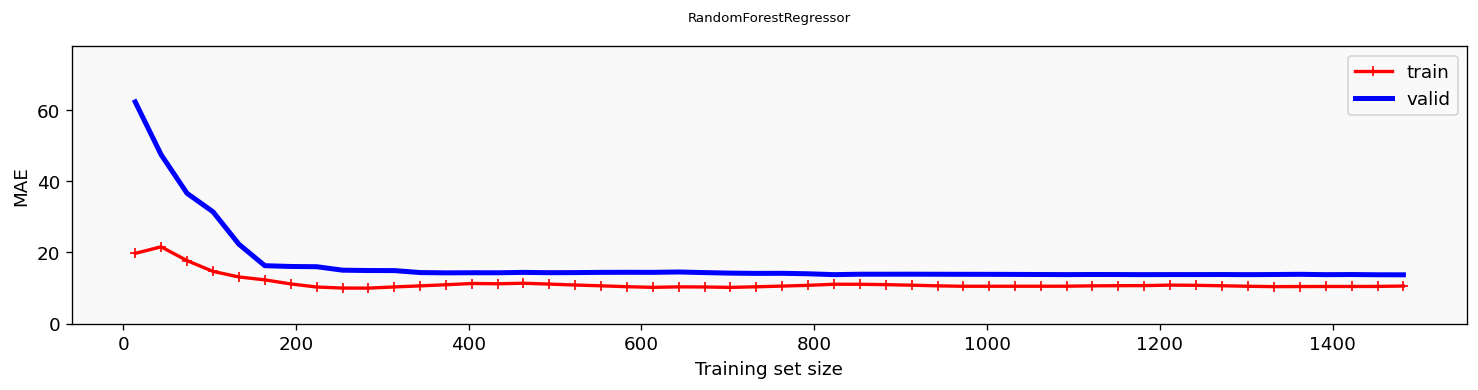

In [15]:
import matplotlib.pyplot as plt
import numpy as np

def _plot_learning_curve(estimator, train_sizes, train_scores, valid_scores, metric='MAE', plt_text='', ax=None):
    train_errors = -train_scores.mean(axis=1)
    valid_errors = -valid_scores.mean(axis=1)
    ax = plt.gca() if not ax else ax
    ax.plot(train_sizes, train_errors, "r-+", linewidth=2, label="train")
    ax.plot(train_sizes, valid_errors, "b-", linewidth=3, label="valid")
    ax.set_xlabel("Training set size")
    ax.set_ylabel(f'{metric}')
    # plt.gca().set_xscale("log", nonpositive='clip')
    ax.grid()
    ax.legend(loc="upper right")
    ax.set_ylim(bottom=0, top=1.25*max([max(train_errors), max(valid_errors)]))
    ax.set_title(f'{estimator.__class__.__name__}\n{plt_text}', fontsize=8)

from sklearn.model_selection import learning_curve
# insert your code here.

train_sizes, train_scores, valid_scores = learning_curve(estimator, X_train, y_train, train_sizes=np.linspace(0.01, 1.0, 50), cv=5, scoring="neg_mean_absolute_error")

fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(15, 3), sharey=True, sharex=True)
_plot_learning_curve(estimator, train_sizes, train_scores, valid_scores, metric='MAE', plt_text='', ax=None)

## Isolation Forest (Unsupervised Learning)

### Train-test splitting and model fitting

No shuffle for temporal data

In [18]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import IsolationForest

features = [
    "pm2_5_lag_1d", "pm2_5_lag_2d", "pm2_5_lag_7d",
    "pm2_5_roll_mean_7d",
    "pm2_5_roll_std_7d",

    "temp_mean", "precip_total",
    "wind_speed_mean",

    "doy_sin", "doy_cos",
    "is_haze_season",
]

dff.index = pd.to_datetime(dff['date'])

model_df = dff[features].dropna()
X = model_df[features]

print('Number of Features: ', len(features))
print('Features Names: ', features)


X_train, X_test = train_test_split(X, test_size = 0.15, random_state = 0, shuffle=False)

clf = IsolationForest(max_samples=100, contamination=0.05, random_state=0)
clf.fit(X_train)

Number of Features:  11
Features Names:  ['pm2_5_lag_1d', 'pm2_5_lag_2d', 'pm2_5_lag_7d', 'pm2_5_roll_mean_7d', 'pm2_5_roll_std_7d', 'temp_mean', 'precip_total', 'wind_speed_mean', 'doy_sin', 'doy_cos', 'is_haze_season']


,"n_estimators n_estimators: int, default=100The number of base estimators in the ensemble.",100
,"max_samples max_samples: ""auto"", int or float, default=""auto""The number of samples to draw from X to train each base estimator.- If int, then draw `max_samples` samples.- If float, then draw `max_samples * X.shape[0]` samples.- If ""auto"", then `max_samples=min(256, n_samples)`.If max_samples is larger than the number of samples provided,all samples will be used for all trees (no sampling).",100
,"contamination contamination: 'auto' or float, default='auto'The amount of contamination of the data set, i.e. the proportionof outliers in the data set. Used when fitting to define the thresholdon the scores of the samples.- If 'auto', the threshold is determined as in the original paper.- If float, the contamination should be in the range (0, 0.5]... versionchanged:: 0.22 The default value of ``contamination`` changed from 0.1 to ``'auto'``.",0.05
,"max_features max_features: int or float, default=1.0The number of features to draw from X to train each base estimator.- If int, then draw `max_features` features.- If float, then draw `max(1, int(max_features * n_features_in_))` features.Note: using a float number less than 1.0 or integer less than number offeatures will enable feature subsampling and leads to a longer runtime.",1.0
,"bootstrap bootstrap: bool, default=FalseIf True, individual trees are fit on random subsets of the trainingdata sampled with replacement. If False, sampling without replacementis performed.",False
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for :meth:`fit`. ``None`` means 1unless in a :obj:`joblib.parallel_backend` context. ``-1`` means usingall processors. See :term:`Glossary ` for more details.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo-randomness of the selection of the featureand split values for each branching step and each tree in the forest.Pass an int for reproducible results across multiple function calls.See :term:`Glossary `.",0
,"verbose verbose: int, default=0Controls the verbosity of the tree building process.",0
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fitand add more estimators to the ensemble, otherwise, just fit a wholenew forest. See :term:`the Glossary `... versionadded:: 0.21",False


### Predict on test data

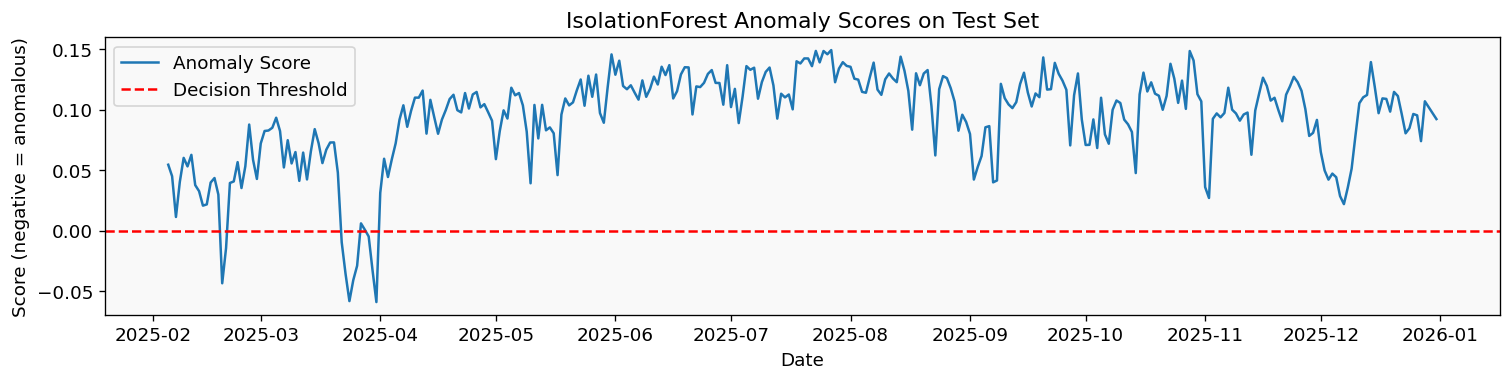

Anomalies detected: 10 / 328


In [20]:
X_test_pred = clf.predict(X_test)

X_test_scores = clf.decision_function(X_test)

results = X_test.copy()
results['anomaly'] = X_test_pred
results['anomaly_score'] = X_test_scores

fig, ax = plt.subplots(figsize=(15, 3))
ax.plot(results.index, results['anomaly_score'], label='Anomaly Score')
ax.axhline(0, color='red', linestyle='--', label='Decision Threshold')
ax.set_title('IsolationForest Anomaly Scores on Test Set')
ax.set_xlabel('Date')
ax.set_ylabel('Score (negative = anomalous)')
ax.legend()
ax.grid()
plt.show()

print(f"Anomalies detected: {(X_test_pred == -1).sum()} / {len(X_test_pred)}")

### Predict on all data

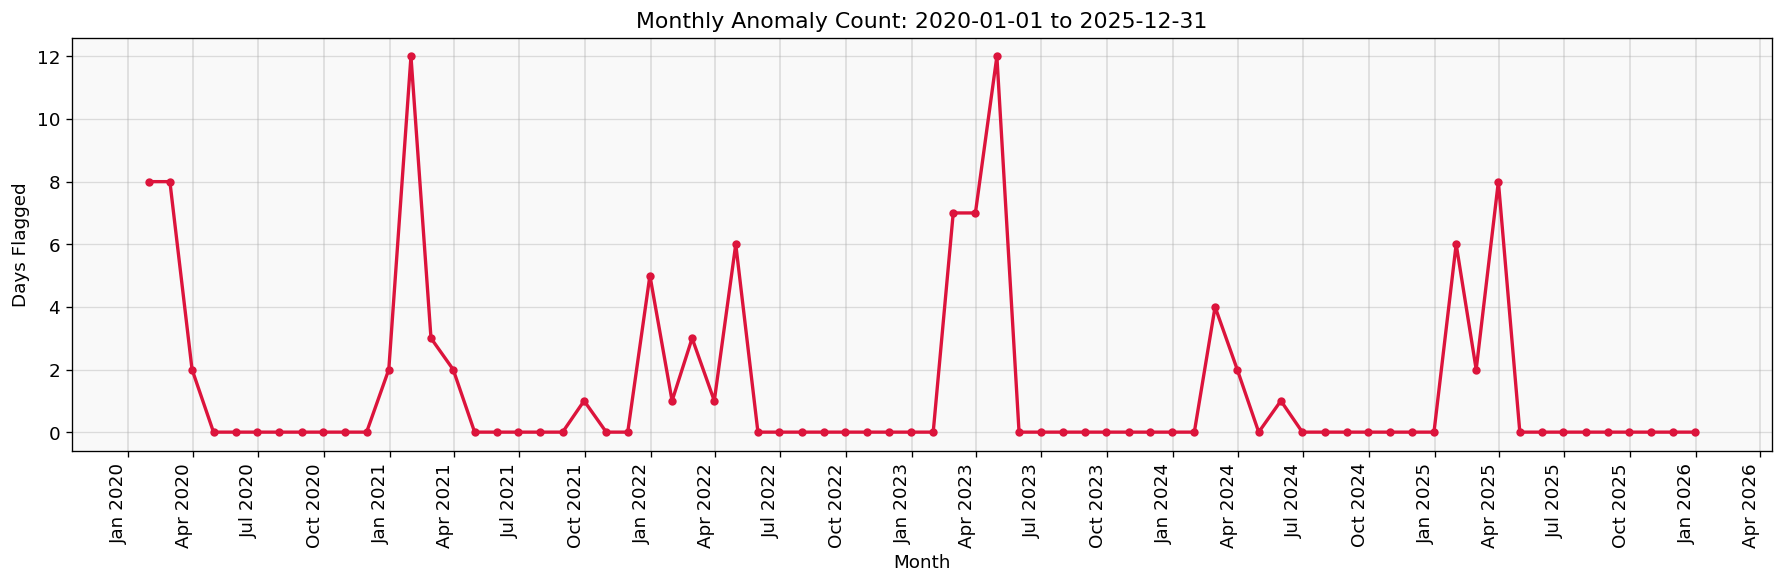

In [22]:
import matplotlib.dates as mdates

X_all_pred = clf.predict(X)

X_all_scores = clf.decision_function(X)

results = X.copy()
results['anomaly'] = X_all_pred
results['anomaly_score'] = X_all_scores

results.index = pd.to_datetime(results.index)

start_date = "2020-01-01"
end_date   = "2025-12-31"

mask = (results.index >= start_date) & (results.index <= end_date)
results_range = results.loc[mask]

monthly = results_range.resample('ME').agg(
    pm2_5        = ('pm2_5_lag_1d', 'mean'),      
    anomaly_score = ('anomaly_score', 'mean'),
    anomaly_count = ('anomaly', lambda x: (x == -1).sum())
)

fig, ax = plt.subplots(figsize=(15, 5))

ax.plot(monthly.index, monthly['anomaly_count'], color='crimson', linewidth=2, marker='o', markersize=4)

# # Annual labels only
# ax.xaxis.set_major_locator(mdates.YearLocator())
# ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

# # Quarterly minor gridlines (no labels)
# ax.xaxis.set_minor_locator(mdates.MonthLocator(bymonth=[1, 4, 7, 10]))

ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.xticks(rotation=90, ha='right')

ax.grid(which='major', axis='x', linewidth=1.0)
ax.grid(which='minor', axis='x', linewidth=0.4, linestyle='--', alpha=0.5)
ax.grid(axis='y', alpha=0.4)

ax.set_ylabel('Days Flagged')
ax.set_xlabel('Month')
ax.set_title(f'Monthly Anomaly Count: {start_date} to {end_date}')

plt.tight_layout()
plt.show()

### Visualize anomalous months

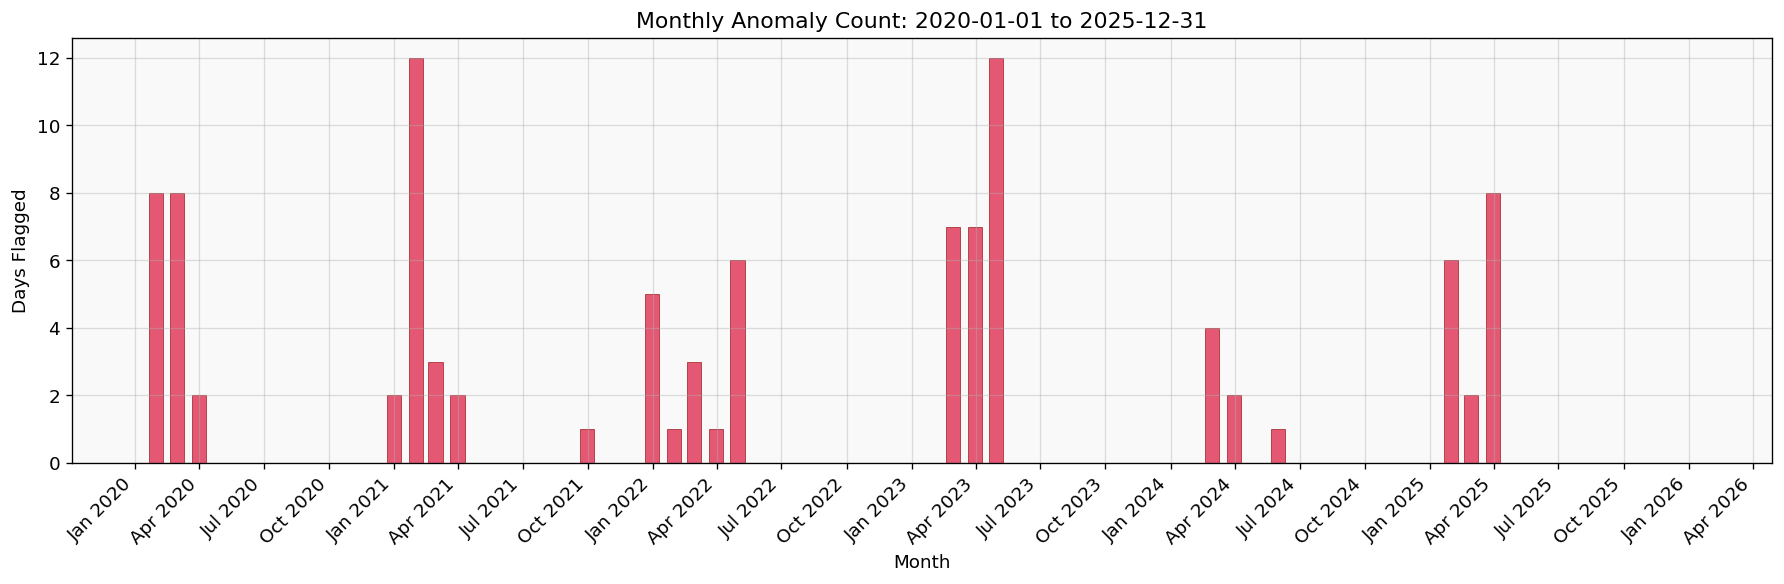

In [24]:
fig, ax = plt.subplots(figsize=(15, 5))

ax.bar(monthly.index, monthly['anomaly_count'], 
       width=20,           # bar width in days
       color='crimson', 
       alpha=0.7,
       edgecolor='darkred', 
       linewidth=0.5)

ax.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1, 4, 7, 10]))  # every 3 months
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.xticks(rotation=45, ha='right')

ax.set_ylabel('Days Flagged')
ax.set_xlabel('Month')
ax.set_title(f'Monthly Anomaly Count: {start_date} to {end_date}')
ax.grid(axis='y', alpha=0.4)

plt.tight_layout()
plt.show()

### Predictive Modelling

In [64]:
# Step 4: Predictive Model
print("STEP 4 — PREDICTIVE MODELLING")
print("="*60)

import warnings
warnings.filterwarnings("ignore")

from sklearn.linear_model    import LinearRegression, RidgeCV
from sklearn.ensemble        import RandomForestRegressor
from sklearn.preprocessing   import StandardScaler
from sklearn.metrics         import mean_absolute_error, mean_squared_error, r2_score
from xgboost                 import XGBRegressor
from lightgbm                import LGBMRegressor
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Features & split config 
EXCLUDE = [
    "date", "pm2_5_target_t1", "pm2_5_log",
    "month", "year", "month_name", "pm2_5",
]
FEATURES = [c for c in dff_model_ready.columns if c not in EXCLUDE]
print(f"  Total features: {len(FEATURES)}")
print(f"  {sorted(FEATURES)}")

TARGET       = "pm2_5_target_t1"
TEST_FRAC    = 0.20   # train = 80%, test = 20%

STEP 4 — PREDICTIVE MODELLING
  Total features: 35
  ['day_of_week', 'day_of_year', 'doy_cos', 'doy_sin', 'is_dry_day', 'is_haze_season', 'is_heavy_rain', 'is_weekend', 'month_cos', 'month_sin', 'pm2_5_lag_14d', 'pm2_5_lag_1d', 'pm2_5_lag_2d', 'pm2_5_lag_3d', 'pm2_5_lag_7d', 'pm2_5_roll_mean_14d', 'pm2_5_roll_mean_30d', 'pm2_5_roll_mean_3d', 'pm2_5_roll_mean_7d', 'pm2_5_roll_std_14d', 'pm2_5_roll_std_30d', 'pm2_5_roll_std_3d', 'pm2_5_roll_std_7d', 'precip_total', 'quarter', 'temp_max', 'temp_mean', 'temp_min', 'week_of_year', 'wind_cos', 'wind_dir_dominant', 'wind_sin', 'wind_speed_max', 'wind_speed_mean', 'wind_speed_roll_7d']


In [65]:
# 4A. Prepare data 
print("\n[4A] Preparing features and target…")
data = dff[FEATURES + [TARGET, "date"]].dropna().copy().reset_index(drop=True)

X      = data[FEATURES].values
y      = data[TARGET].values
dates  = data["date"].values

split  = int(len(data) * (1 - TEST_FRAC))
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]
dates_test      = dates[split:]

print(f"  Train: {split:,} rows  |  Test: {len(X_test):,} rows")
print(f"  Train: {data['date'].iloc[0].date()} → {data['date'].iloc[split-1].date()}")
print(f"  Test : {data['date'].iloc[split].date()} → {data['date'].iloc[-1].date()}")

# Scale for Linear Regression
scaler     = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

# 4B. Metrics helper 
def compute_metrics(name, y_true, y_pred, y_train_naive=None):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / np.where(y_true == 0, 1, y_true))) * 100

    # MASE = MAE / MAE_naive (naive = yesterday's value)
    if y_train_naive is not None:
        naive_mae = np.mean(np.abs(np.diff(y_train_naive)))
        mase = mae / naive_mae if naive_mae != 0 else np.nan
    else:
        mase = np.nan

    mbe  = np.mean(y_pred - y_true)   # Mean Bias Error (+overpredict, -underpredict)

    print(f"  {name:<32}  MAE={mae:.2f}  RMSE={rmse:.2f}  "
          f"MAPE={mape:.1f}%  MASE={mase:.3f}  R²={r2:.4f}  MBE={mbe:+.2f}")
    return {"Model": name, "MAE": round(mae,3), "RMSE": round(rmse,3),
            "MAPE%": round(mape,2), "MASE": round(mase,4),
            "R2": round(r2,4), "MBE": round(mbe,3)}

results = []


[4A] Preparing features and target…
  Train: 1,738 rows  |  Test: 435 rows
  Train: 2020-01-15 → 2024-10-18
  Test : 2024-10-19 → 2025-12-28


In [66]:
# 4C. SARIMA benchmark - (Seasonal Autoregressive Integrated Moving Average)
print("\n[4C] Fitting SARIMA(2,1,2)(1,1,1,7) benchmark…")
sarima_fit = SARIMAX(
    y_train,
    order=(2,1,2),
    seasonal_order=(1,1,1,7),
    enforce_stationarity=False,
    enforce_invertibility=False,
).fit(disp=False)

sarima_pred = np.array(sarima_fit.forecast(steps=len(y_test)))
results.append(compute_metrics("SARIMA(2,1,2)(1,1,1,7)", y_test, sarima_pred, y_train))


[4C] Fitting SARIMA(2,1,2)(1,1,1,7) benchmark…
  SARIMA(2,1,2)(1,1,1,7)            MAE=24.33  RMSE=34.95  MAPE=25.6%  MASE=2.184  R²=-0.4651  MBE=-21.77


In [67]:
# 4D. Base models
print("\n[4D] Training base models…")

models = { # param = (model, use_scaled (true/false)) 
    "Linear Regression": (LinearRegression(), True),  
    "Random Forest":     (RandomForestRegressor(
                            n_estimators=300, max_depth=10,
                            min_samples_leaf=10, min_samples_split=20,
                            max_features=0.5, random_state=42, n_jobs=-1), False),
    "XGBoost":           (XGBRegressor(
                            n_estimators=500, learning_rate=0.05,
                            max_depth=6, subsample=0.8,
                            colsample_bytree=0.6, min_child_weight=10,
                            random_state=42, verbosity=0), False),
    "LightGBM":          (LGBMRegressor(
                            n_estimators=500, learning_rate=0.05,
                            max_depth=6, subsample=0.8,
                            colsample_bytree=0.6, min_child_weight=10,
                            random_state=42, verbose=-1), False),
}

base_train_preds = {}
base_test_preds  = {}

for name, (model, scaled) in models.items():
    Xtr = X_train_sc if scaled else X_train
    Xte = X_test_sc  if scaled else X_test
    model.fit(Xtr, y_train)
    base_train_preds[name] = model.predict(Xtr)
    base_test_preds[name]  = model.predict(Xte)
    results.append(compute_metrics(name, y_test, base_test_preds[name], y_train))


[4D] Training base models…
  Linear Regression                 MAE=11.06  RMSE=14.64  MAPE=14.4%  MASE=0.992  R²=0.7429  MBE=-3.32
  Random Forest                     MAE=11.95  RMSE=15.47  MAPE=15.9%  MASE=1.072  R²=0.7128  MBE=+0.63
  XGBoost                           MAE=12.48  RMSE=15.81  MAPE=16.8%  MASE=1.121  R²=0.7003  MBE=+1.34
  LightGBM                          MAE=11.95  RMSE=15.19  MAPE=16.2%  MASE=1.073  R²=0.7235  MBE=+1.35


In [68]:
# 4E. Stacking ensemble 
print("\n[4E] Training stacking meta-learner (RidgeCV)…")
S_train = np.column_stack(list(base_train_preds.values()))
S_test  = np.column_stack(list(base_test_preds.values()))

meta = RidgeCV(alphas=[0.01, 0.1, 1.0, 10.0, 100.0], cv=5)
meta.fit(S_train, y_train)
print(f"  Best alpha: {meta.alpha_}")

stack_pred = meta.predict(S_test)
results.append(compute_metrics("Stacking (RidgeCV)", y_test, stack_pred, y_train))


[4E] Training stacking meta-learner (RidgeCV)…
  Best alpha: 0.1
  Stacking (RidgeCV)                MAE=13.24  RMSE=16.82  MAPE=17.8%  MASE=1.189  R²=0.6609  MBE=+1.51


In [69]:
# 4F. Results table
print("\n[4F] Model comparison summary:")
print("-"*75)
results_df = pd.DataFrame(results).sort_values("RMSE").reset_index(drop=True)
print(results_df.to_string(index=False))
results_df.to_csv(f"{OUTPUT_DIR}/model_comparison.csv", index=False)


[4F] Model comparison summary:
---------------------------------------------------------------------------
                 Model    MAE   RMSE  MAPE%   MASE      R2     MBE
     Linear Regression 11.056 14.642  14.44 0.9925  0.7429  -3.318
              LightGBM 11.949 15.186  16.17 1.0726  0.7235   1.348
         Random Forest 11.948 15.475  15.87 1.0725  0.7128   0.631
               XGBoost 12.483 15.808  16.79 1.1205  0.7003   1.336
    Stacking (RidgeCV) 13.245 16.816  17.80 1.1889  0.6609   1.510
SARIMA(2,1,2)(1,1,1,7) 24.327 34.953  25.55 2.1836 -0.4651 -21.774


In [70]:
# Check how correlated base model predictions are
pred_df = pd.DataFrame(base_test_preds)
print(pred_df.corr().round(3))

                   Linear Regression  Random Forest  XGBoost  LightGBM
Linear Regression              1.000          0.961    0.939     0.940
Random Forest                  0.961          1.000    0.965     0.966
XGBoost                        0.939          0.965    1.000     0.987
LightGBM                       0.940          0.966    0.987     1.000


### I thought stacking the model would obviously improve the prediction but the correletion between each model is well above 90% so meta learner can't find a meaningful combination and improves it.

### Interesting EDA

In [82]:
# 4G. Walk-forward validation chart
# Shows how each model's MAE evolves as more data is seen
# Uses expanding window: train on first N rows, score on next 30-day chunk
print("\n[4G] Walk-forward validation (expanding window)…")

WF_START  = int(len(data) * 0.4)   # start after 40% of data
WF_STEP   = 30                      # evaluate every 30 days

wf_dates, wf_results = [], {name: [] for name in list(models.keys()) + ["Linear Regression"]}

for end in range(WF_START, len(data) - WF_STEP, WF_STEP):
    X_wf_tr = X[:end]
    y_wf_tr = y[:end]
    X_wf_te = X[end:end+WF_STEP]
    y_wf_te = y[end:end+WF_STEP]
    X_wf_tr_sc = scaler.fit_transform(X_wf_tr)
    X_wf_te_sc = scaler.transform(X_wf_te)

    wf_dates.append(dates[end])

    for name, (model, scaled) in models.items():
        Xtr = X_wf_tr_sc if scaled else X_wf_tr
        Xte = X_wf_te_sc if scaled else X_wf_te
        model.fit(Xtr, y_wf_tr)
        pred = model.predict(Xte)
        wf_results[name].append(mean_absolute_error(y_wf_te, pred))

fig, ax = plt.subplots(figsize=(16, 5))
colors_wf = [ORANGE, BROWN, GOLD, "#5B8DB8"]
for (name, maes), col in zip(wf_results.items(), colors_wf):
    ax.plot(wf_dates, maes, label=name, lw=1.5, color=col)

# Mark train/test boundary
ax.axvline(dates[split], color="red", lw=1.5, ls="--", label="Train/Test split")
ax.set_title("Walk-Forward Validation: MAE as Training Window Expands",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Date"); ax.set_ylabel("MAE (µg/m³)")
ax.legend(fontsize=9); fig.tight_layout()
fig.savefig(f"{OUTPUT_DIR}/step4_walkforward_mae.png")
plt.close()

# ── 4H. Predictions vs actual ───────────────────────────────
print("[4H] Plotting predictions vs actuals…")
all_preds = {"SARIMA": sarima_pred,
             **base_test_preds,
             "Stacking (RidgeCV)": stack_pred}

fig, axes = plt.subplots(len(all_preds), 1,
                          figsize=(16, 4*len(all_preds)), sharex=True)

for ax, (name, pred) in zip(axes, all_preds.items()):
    ax.plot(dates_test, y_test, color="gray",  lw=0.8, alpha=0.6, label="Actual")
    ax.plot(dates_test, pred,   color=ORANGE,  lw=1.2, label=f"Predicted")
    mae  = mean_absolute_error(y_test, pred)
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    r2   = r2_score(y_test, pred)
    ax.set_title(f"{name}   MAE={mae:.2f}  RMSE={rmse:.2f}  R²={r2:.4f}",
                 fontsize=11, fontweight="bold")
    ax.set_ylabel("PM2.5 (µg/m³)"); ax.legend(fontsize=8)

axes[-1].set_xlabel("Date")
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
fig.suptitle("Model Predictions vs Actual PM2.5, only Test Set",
             fontsize=14, fontweight="bold", y=1.005)
fig.tight_layout()
fig.savefig(f"{OUTPUT_DIR}/step4_predictions.png", bbox_inches="tight")
plt.close()

# 4I. Residual analysis
print("[4I] Plotting residuals…")
fig, axes = plt.subplots(len(all_preds), 2, figsize=(14, 3.5*len(all_preds)))

for i, (name, pred) in enumerate(all_preds.items()):
    residuals = y_test - pred
    axes[i,0].plot(dates_test, residuals, color=ORANGE, lw=0.8, alpha=0.7)
    axes[i,0].axhline(0, color="red", lw=1, ls="--")
    axes[i,0].set_title(f"{name} — Residuals over time", fontsize=10, fontweight="bold")
    axes[i,0].set_ylabel("Residual (µg/m³)")

    axes[i,1].hist(residuals, bins=40, color=BROWN, edgecolor="white", alpha=0.8)
    axes[i,1].axvline(0, color="red", lw=1.5, ls="--")
    axes[i,1].set_title(f"{name} — Residual distribution", fontsize=10, fontweight="bold")
    axes[i,1].set_xlabel("Residual (µg/m³)")

axes[-1,0].xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
fig.suptitle("Residual Analysis per Model", fontsize=13, fontweight="bold")
fig.tight_layout()
fig.savefig(f"{OUTPUT_DIR}/step4_residuals.png", bbox_inches="tight")
plt.close()

# 4J. Metrics comparison bar chart 
print("[4J] Plotting metric comparison charts…")
fig, axes = plt.subplots(1, 5, figsize=(20, 5))
metrics_to_plot = ["MAE", "RMSE", "MAPE%", "MASE", "R2"]
bar_colors = [ORANGE if row["Model"] != "Stacking (RidgeCV)" else BROWN
              for _, row in results_df.iterrows()]

for ax, metric in zip(axes, metrics_to_plot):
    bars = ax.barh(results_df["Model"], results_df[metric],
                   color=bar_colors, edgecolor="white")
    ax.set_title(metric, fontweight="bold", fontsize=11)
    ax.invert_yaxis()
    for bar, val in zip(bars, results_df[metric]):
        ax.text(bar.get_width() * 1.01, bar.get_y() + bar.get_height()/2,
                f"{val:.3f}", va="center", fontsize=8)

fig.suptitle("Model Performance Comparison for All Metrics",
             fontsize=13, fontweight="bold")
fig.tight_layout()
fig.savefig(f"{OUTPUT_DIR}/step4_metrics_comparison.png", bbox_inches="tight")
plt.close()

# 4K. Feature importance (tree models only) 
print("[4K] Plotting feature importances…")
tree_models = {k: v[0] for k, v in models.items()
               if k in ["Random Forest", "XGBoost", "LightGBM"]}

fig, axes = plt.subplots(1, len(tree_models), figsize=(16, 5))
for ax, (name, model) in zip(axes, tree_models.items()):
    imp = pd.Series(model.feature_importances_, index=FEATURES).sort_values()
    imp.plot.barh(ax=ax, color=ORANGE, edgecolor="white")
    ax.set_title(f"{name}\nFeature Importances", fontweight="bold", fontsize=10)
    ax.set_xlabel("Importance")

fig.tight_layout()
fig.savefig(f"{OUTPUT_DIR}/step4_feature_importance.png", bbox_inches="tight")
plt.close()

# 4L. Scatter: predicted vs actual 
print("[4L] Plotting predicted vs actual scatter…")
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for ax, (name, pred) in zip(axes, all_preds.items()):
    ax.scatter(y_test, pred, alpha=0.25, s=8, color=ORANGE)
    lims = [min(y_test.min(), pred.min()), max(y_test.max(), pred.max())]
    ax.plot(lims, lims, "r--", lw=1.5, label="Perfect fit")
    r2 = r2_score(y_test, pred)
    ax.set_title(f"{name}  R²={r2:.4f}", fontsize=10, fontweight="bold")
    ax.set_xlabel("Actual PM2.5"); ax.set_ylabel("Predicted PM2.5")
    ax.legend(fontsize=8)

# Hide unused subplot if odd number of models
for ax in axes[len(all_preds):]:
    ax.set_visible(False)

fig.suptitle("Predicted vs Actual PM2.5, only Test Set",
             fontsize=13, fontweight="bold")
fig.tight_layout()
fig.savefig(f"{OUTPUT_DIR}/step4_scatter_pred_actual.png", bbox_inches="tight")
plt.close()

print(f"\n Step 4 complete. All outputs saved to {OUTPUT_DIR}/")


[4G] Walk-forward validation (expanding window)…
[4H] Plotting predictions vs actuals…
[4I] Plotting residuals…
[4J] Plotting metric comparison charts…
[4K] Plotting feature importances…
[4L] Plotting predicted vs actual scatter…

 Step 4 complete. All outputs saved to outputs/
